**Boston Dataset**

This data frame contains the following columns:

`crim`
per capita crime rate by town.

`zn`
proportion of residential land zoned for lots over 25,000 sq.ft.

`indus`
proportion of non-retail business acres per town.

`chas`
Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).

`nox`
nitrogen oxides concentration (parts per 10 million).

`rm`
average number of rooms per dwelling.

`age`
proportion of owner-occupied units built prior to 1940.

`dis`
weighted mean of distances to five Boston employment centres.

`rad`
index of accessibility to radial highways.

`tax`
full-value property-tax rate per $10,000.

`ptratio`
pupil-teacher ratio by town.

`black`
1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town.

`lstat`
lower status of the population (percent).

`medv`
median value of owner-occupied homes in $1000s.

# Import libraries

In [301]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

# Eksplorasi data

## Load data

In [302]:
df = pd.read_csv('/content/boston.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.0063,18.0000,2.3100,0,0.5380,6.5750,65.2000,4.0900,1,296,15.3000,396.9000,4.9800,24.0000
1,0.0273,0.0000,7.0700,0,0.4690,6.4210,78.9000,4.9671,2,242,17.8000,396.9000,9.1400,21.6000
2,0.0273,0.0000,7.0700,0,0.4690,7.1850,61.1000,4.9671,2,242,17.8000,392.8300,4.0300,34.7000
3,0.0324,0.0000,2.1800,0,0.4580,6.9980,45.8000,6.0622,3,222,18.7000,394.6300,2.9400,33.4000
4,0.0691,0.0000,2.1800,0,0.4580,7.1470,54.2000,6.0622,3,222,18.7000,396.9000,5.3300,36.2000


In [303]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  black    506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [304]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,506.0000,506.0000,506.0000,506.0000,506.0000,506.0000,506.0000,506.0000,506.0000,506.0000,506.0000,506.0000,506.0000,506.0000
mean,3.6135,11.3636,11.1368,0.0692,0.5547,6.2846,68.5749,3.7950,9.5494,408.2372,18.4555,356.6740,12.6531,22.5328
std,8.6015,23.3225,6.8604,0.2540,0.1159,0.7026,28.1489,2.1057,8.7073,168.5371,2.1649,91.2949,7.1411,9.1971
min,0.0063,0.0000,0.4600,0.0000,0.3850,3.5610,2.9000,1.1296,1.0000,187.0000,12.6000,0.3200,1.7300,5.0000
25%,0.0820,0.0000,5.1900,0.0000,0.4490,5.8855,45.0250,2.1002,4.0000,279.0000,17.4000,375.3775,6.9500,17.0250
50%,0.2565,0.0000,9.6900,0.0000,0.5380,6.2085,77.5000,3.2074,5.0000,330.0000,19.0500,391.4400,11.3600,21.2000
75%,3.6771,12.5000,18.1000,0.0000,0.6240,6.6235,94.0750,5.1884,24.0000,666.0000,20.2000,396.2250,16.9550,25.0000
max,88.9762,100.0000,27.7400,1.0000,0.8710,8.7800,100.0000,12.1265,24.0000,711.0000,22.0000,396.9000,37.9700,50.0000


**Dataset Overview**:

Didalam dataset boston ini sudah memuat semua variabel yang mungkin diperlukan untuk membuat sebuah model dengan tujuan memprediksi harga rumah (`medv`).
Dalam membeli rumah umumnya seseorang akan mempertimbangkan berbagai macam hal. Mulai dari seputar rumah itu sendiri seperti jumlah kamar tidur (`rm`), umur bangunan (`age`) serta pajak bangunan tersebut (`tax`). Selain itu pembeli juga akan mempertimbangkan terkait aspek lingkungan seperti tingkat kriminalitas di daerah tersebut (`crim`), dan kualitas udara (`nox`) serta aksesibilitas ke fasilitas pendidikan (`ptratio`), akses ke pusat kota / lapangan pekerjaan (`dis`) ataupun kemudahan akses ke jalan tol (`rad`).

Variabel - variabel tersebut biasanya dapat mempengaruhi harga suatu rumah. Sebagai contoh, rumah yang memiliki banyak kamar tidur biasanya memiliki harga yang lebih tinggi, karena dapat menampung lebih banyak orang dan umumnya memiliki luas bangunan yang lebih luas. Akan tetapi, meskipun rumah tersebut memiliki banyak kamar tidur namun rumah tersebut berada di lingkungan dengan tingkat kriminalitas yang tinggi ataupun aksesnya ke pusat kota atau pusat lapangan pekerjaan biasanya harga rumahnya akan lebih rendah, karena pembeli tidak hanya mempertimbangkan dari satu aspek kualitas rumah itu saja namun dari aspek lain seperti kualitas lingkungan dan kemudahan aksesnya.

Sebagai kesimpulan, variabel yang ada pada dataset boston sudah sangat relevan untuk digunakan dalam membuat sebuah model prediksi harga rumah karena dataset ini tidak hanya bersisi data terkait kualitas bangunan ataupun spesifikasi bangunan itu saja, namun berisi data terkait aspek lainnya seperti kualitas lingkungan dan tingkat kemudahan akses untuk fasilitas vital seperti sekolah, pusat kota / pusat lapangan kerja serta jalan tol.


**Insight Data**:
- Dataset terdiri dari 14 kolom data dan 506 baris data dengan semua kolom data bertipe data numerik dan kolom data `medv` digunakan sebagai target
- `medv` yang merupakan variabel target menunjukkan bahwa rata-rata harga rumah yaitu 22,530 dollar dengan mediannya yaitu sebesar 21,200 dollar dimana harga rumah paling tinggi yaitu 50,000 dollar dan terendah yaitu 5,000 dollar.

## Cek distribusi data

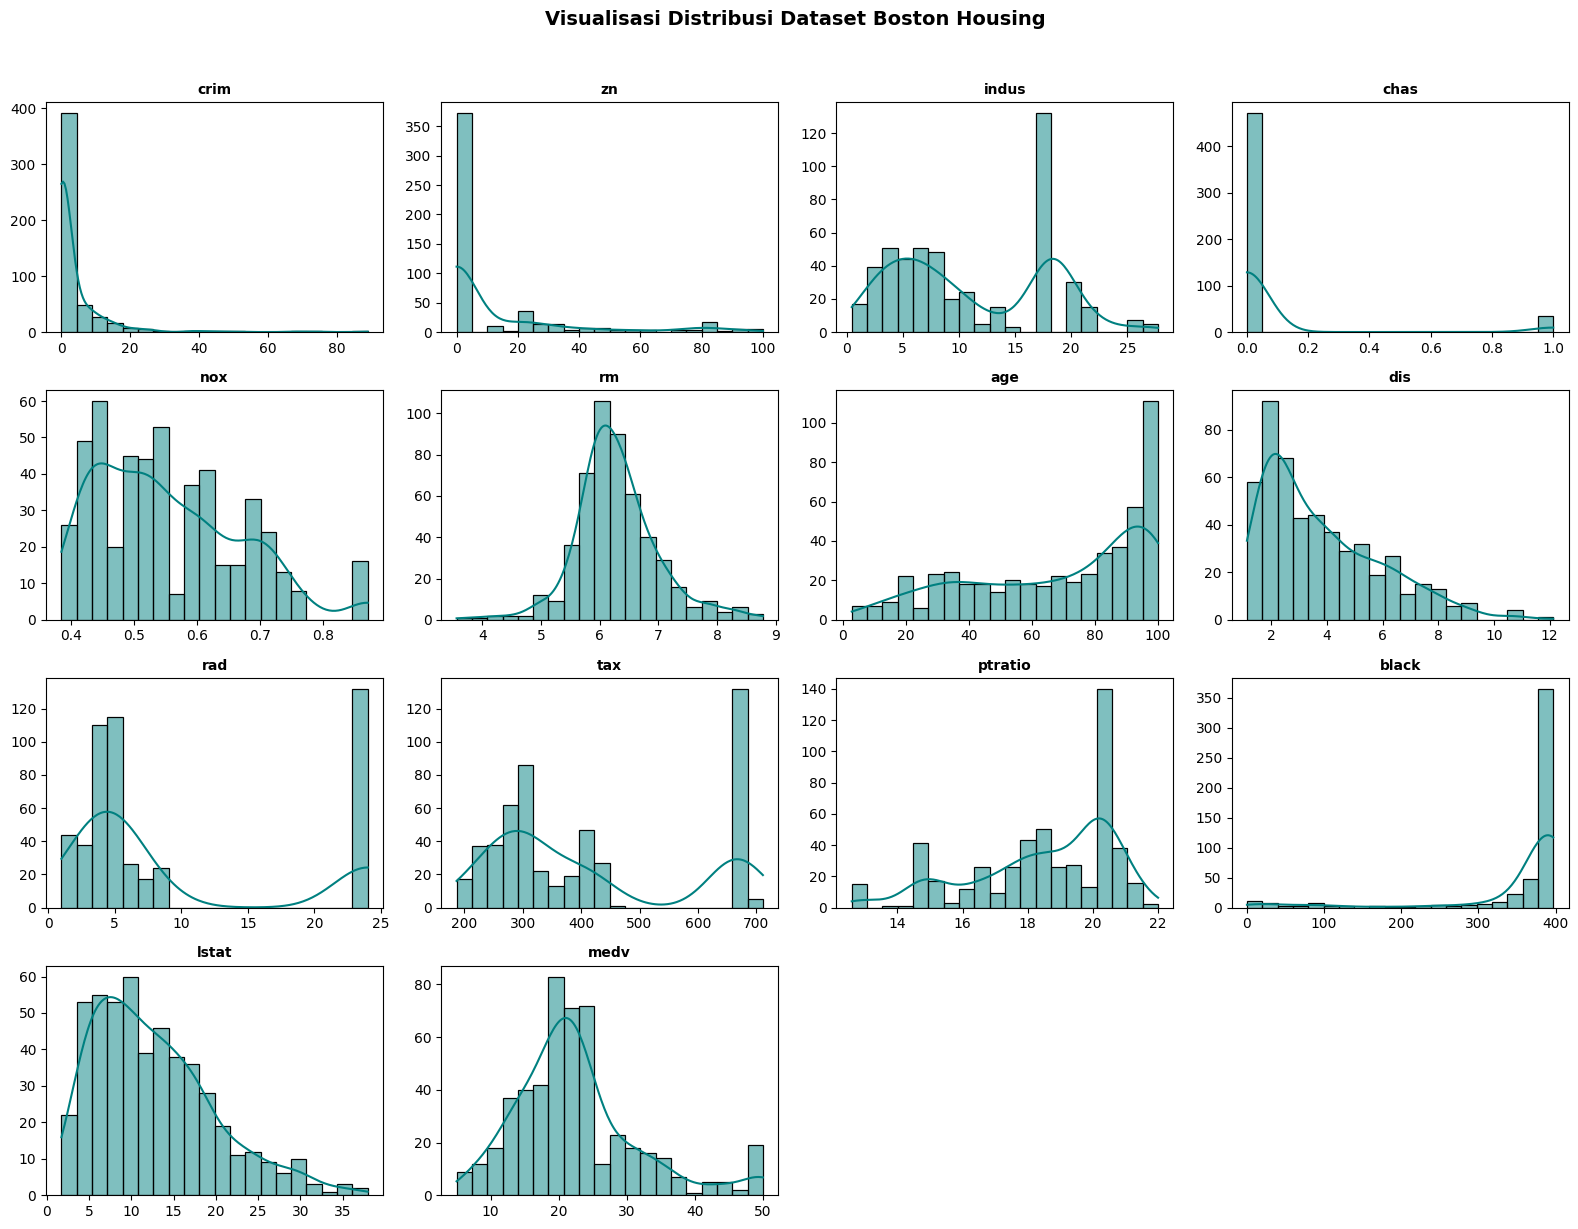

In [305]:
plt.figure(figsize=(16, 12))

for i, col in enumerate(df.columns, 1):
    plt.subplot(4, 4, i)
    sns.histplot(df[col], kde=True, color='teal', bins=20)
    plt.title(f'{col}', fontsize=10, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('')

plt.suptitle('Visualisasi Distribusi Dataset Boston Housing', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**:
- variabel seperti `crim`, `zn`, `nox`, `dis`, `rad`, `tax`, `indus` dan `lstat` terdistribusi secara right skewed.
- variabel seperti `age`, `ptratio` dan `black` terdistribusi secara left skewed.
- variabel `chas` tidak bisa dinilai distribusi datanya karena variabel ini merupakan variabel binner yang mana nilai datanya hanya terdiri dari 0 dan 1
- `rm` merupakan satu - satunya variabel yang terdistribusi secara normal
- `medv` yang merupakan variabel target terdistribusi right skewed, meskipun panjang ekornya tidak terlalu ekstrim dan masih mendekati normal, terlihat dari nilai mean dan mediannya yang masih cukup dekat.

## Cek outlier

In [306]:
# Cek outlier
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print("\nAnalisis Outliers per Kolom Numerik:")
for col in df.columns:
    outlier_count, lower, upper = detect_outliers_iqr(df, col)
    outlier_pct = (outlier_count / len(df)) * 100
    print(f"\n{col}:")
    print(f"  Jumlah Outliers: {outlier_count} ({outlier_pct:.2f}%)")
    print(f"  Batas Bawah: {lower:,.2f}")
    print(f"  Batas Atas: {upper:,.2f}")


Analisis Outliers per Kolom Numerik:

crim:
  Jumlah Outliers: 66 (13.04%)
  Batas Bawah: -5.31
  Batas Atas: 9.07

zn:
  Jumlah Outliers: 68 (13.44%)
  Batas Bawah: -18.75
  Batas Atas: 31.25

indus:
  Jumlah Outliers: 0 (0.00%)
  Batas Bawah: -14.18
  Batas Atas: 37.47

chas:
  Jumlah Outliers: 35 (6.92%)
  Batas Bawah: 0.00
  Batas Atas: 0.00

nox:
  Jumlah Outliers: 0 (0.00%)
  Batas Bawah: 0.19
  Batas Atas: 0.89

rm:
  Jumlah Outliers: 30 (5.93%)
  Batas Bawah: 4.78
  Batas Atas: 7.73

age:
  Jumlah Outliers: 0 (0.00%)
  Batas Bawah: -28.55
  Batas Atas: 167.65

dis:
  Jumlah Outliers: 5 (0.99%)
  Batas Bawah: -2.53
  Batas Atas: 9.82

rad:
  Jumlah Outliers: 0 (0.00%)
  Batas Bawah: -26.00
  Batas Atas: 54.00

tax:
  Jumlah Outliers: 0 (0.00%)
  Batas Bawah: -301.50
  Batas Atas: 1,246.50

ptratio:
  Jumlah Outliers: 15 (2.96%)
  Batas Bawah: 13.20
  Batas Atas: 24.40

black:
  Jumlah Outliers: 77 (15.22%)
  Batas Bawah: 344.11
  Batas Atas: 427.50

lstat:
  Jumlah Outliers: 7 

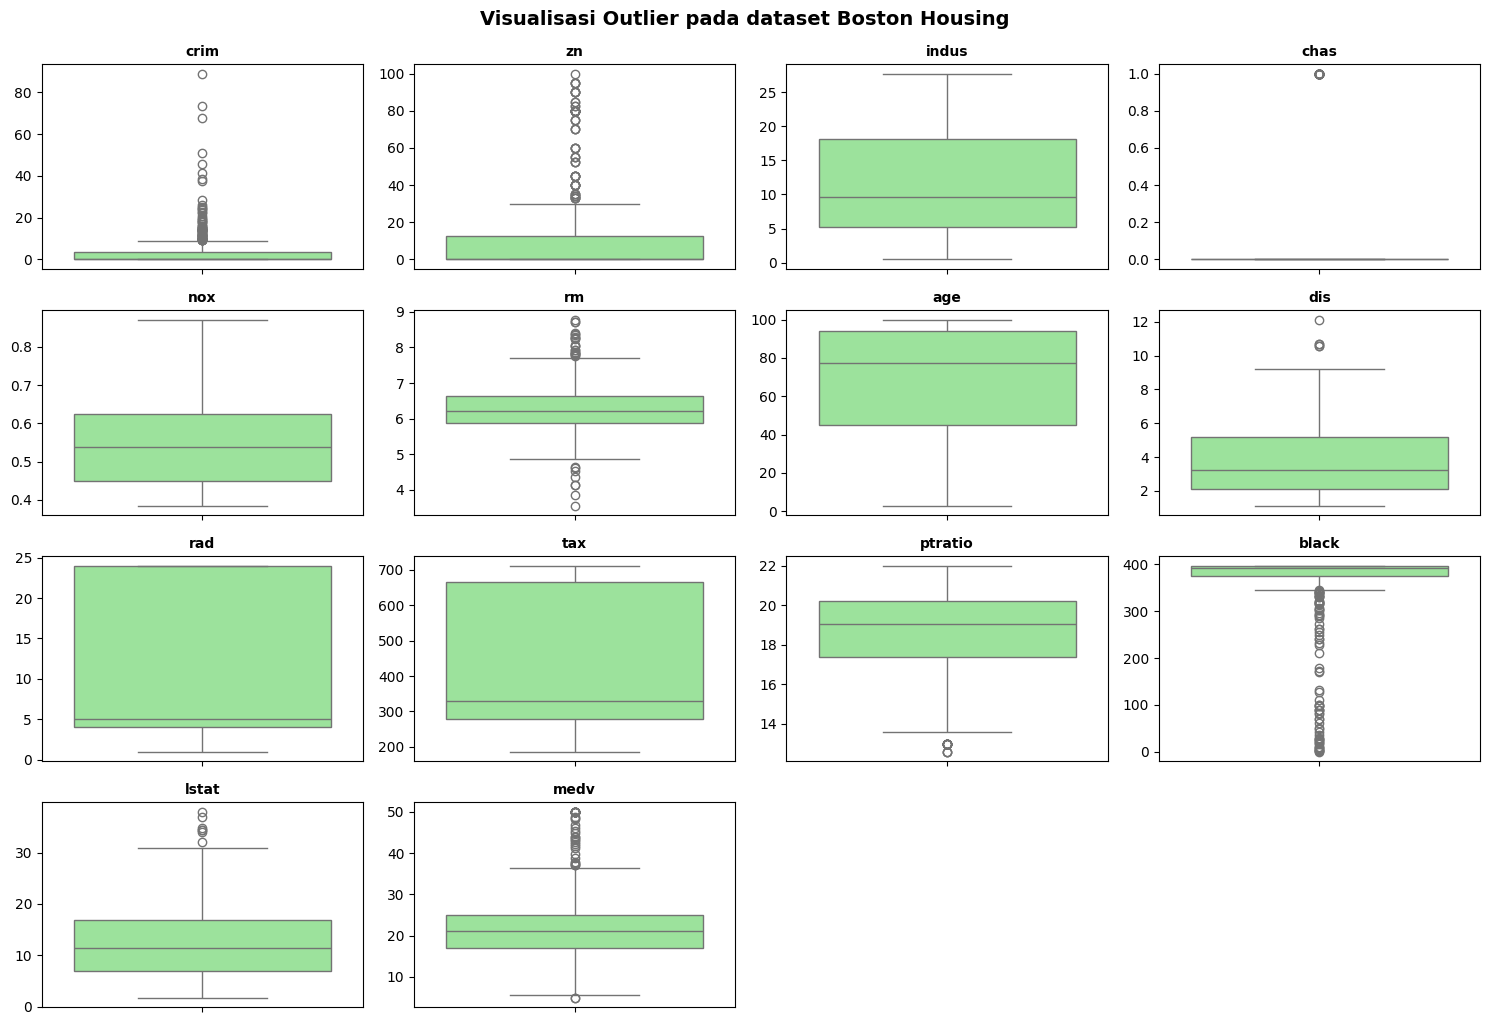

In [307]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(df.columns, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'{col}', fontsize=10, fontweight='bold')
    plt.ylabel('')
    plt.tight_layout()

plt.suptitle('Visualisasi Outlier pada dataset Boston Housing', y=1.02, fontsize=14, fontweight='bold')
plt.show()

**Insight**:

Meskipun terdapat banyak outlier pada dataset, saya memutuskan untuk tidak melakukan handling untuk data data tersebut. Dengan beberapa variabel memiliki 5% hingga 15% nilai yang terindikasi sebagai outlier, apabila saya memutuskan untuk menghapus data-data tersebut nantinya ditakutkan akan mengakibatkan terjadinya distorsi informasi, dimana akan menghilangkan fakta yang ada dilapangan.

Outlier yang ada pada data tersebut bisa dimungkinkan memang karena fakta dilapangan. Sebagai contoh untuk variabel `crim`, dimana ada daerah-daerah yang memang tingkat kriminalitasnya sangat tinggi, dan ada pula daerah yang tingkat kriminalitasnya rendah. Selain itu outlier pada variabel `zn` ataupun `medv` dapat memberikan informasi terkait fakta bahwa terdapat rumah mewah yang ukurannya sangat luas sehingga harganya sanggat tinggi, serta ada pula rumah yang luasnya kecil sehingga harganya rendah.

## Cek missing value

In [308]:
# Check missing value
df.isnull().sum()

,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


## Cek data duplikat

In [309]:
# Check duplicate
df.duplicated().sum()

np.int64(0)

**Insight**:

Seluruh variabel aman dari missing value dan duplicate data.

## Split data

In [310]:
# Split train test
feature = df.drop(columns='medv')
target = df['medv']

# First split: pretrain & test
X_pretrain, X_test, y_pretrain, y_test = train_test_split(feature, target, test_size = 0.2, random_state = 42)

# Second split: train and validation
X_train, X_val, y_train, y_val = train_test_split(X_pretrain, y_pretrain, test_size = 0.2, random_state = 42)

In [311]:
print(f'X_train : {X_train.shape}')
print(f'X_test : {X_test.shape}')
print(f'X_val : {X_val.shape}')
print(f'y_train : {y_train.shape}')
print(f'y_test : {y_test.shape}')
print(f'y_val : {y_val.shape}')

print(f'\nTotal data training: {sum(i.shape[0] for i in [X_train, X_test, X_val])}')
print(f'Total data test: {sum(i.shape[0] for i in [y_train, y_test, y_val])}')

X_train : (323, 13)
X_test : (102, 13)
X_val : (81, 13)
y_train : (323,)
y_test : (102,)
y_val : (81,)

Total data training: 506
Total data test: 506


In [312]:
X_train

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
54,0.0136,75.0000,4.0000,0,0.4100,5.8880,47.6000,7.3197,3,469,21.1000,396.9000,14.8000
28,0.7730,0.0000,8.1400,0,0.5380,6.4950,94.4000,4.4547,4,307,21.0000,387.9400,12.8000
423,7.0504,0.0000,18.1000,0,0.6140,6.1030,85.1000,2.0218,24,666,20.2000,2.5200,23.2900
244,0.2061,22.0000,5.8600,0,0.4310,5.5930,76.5000,7.9549,7,330,19.1000,372.4900,12.5000
111,0.1008,0.0000,10.0100,0,0.5470,6.7150,81.6000,2.6775,6,432,17.8000,395.5900,10.1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,1.2236,0.0000,19.5800,0,0.6050,6.9430,97.4000,1.8773,5,403,14.7000,363.4300,4.5900
199,0.0315,95.0000,1.4700,0,0.4030,6.9750,15.3000,7.6534,3,402,17.0000,396.9000,4.5600
200,0.0178,95.0000,1.4700,0,0.4030,7.1350,13.9000,7.6534,3,402,17.0000,384.3000,4.4500
498,0.2391,0.0000,9.6900,0,0.5850,6.0190,65.3000,2.4091,6,391,19.2000,396.9000,12.9200


**Insight**:

Dataset dibagi menjadi 3, test set sebesar 20% dari total data, training set sebesar 80% dari total data yang kemudian dibagi lagi sebanyak 20% untuk menjadi validation set.

Pembagian dataset menjadi 3 ini bertujuan agar nantinya model dapat bekerja baik tidak hanya saat sesi training, dimana nantinya kinerja model akan ditest menggunakan validation set untuk memastikan kinerjanya sudah baik selama tahap pengembangan sebelum digunakan untuk pengetesan tahap akhir menggunakan test set yang sebelumnya belum pernah dilihat oleh model. Dengan begitu, nantinya apabila model dihadapkan dengan data real dari lapangan, model dapat bekerja dengan baik dengan menghasilkan prediksi yang akurat dan dapat membantu membuat keputusan yang tepat.

## Cek VIF score

In [313]:
# Calculate vif score
X = add_constant(X_train)

vif_df = pd.DataFrame([vif(X.values, i)
                      for i in range(X.shape[1])],
                      index = X.columns).reset_index()

vif_df.columns = ['feature', 'vif_score']
vif_df = vif_df.loc[vif_df.feature != 'const']
vif_df

,feature,vif_score
1,crim,1.7509
2,zn,2.4734
3,indus,3.7420
4,chas,1.1100
5,nox,4.5857
6,rm,1.9722
7,age,3.1274
8,dis,4.3905
9,rad,7.1824
10,tax,8.2681


**Insight**:

Terdapat beberapa fitur dengan VIF Score yang tinggi:
1. `rad` : 7.182
2. `tax` : 8.268

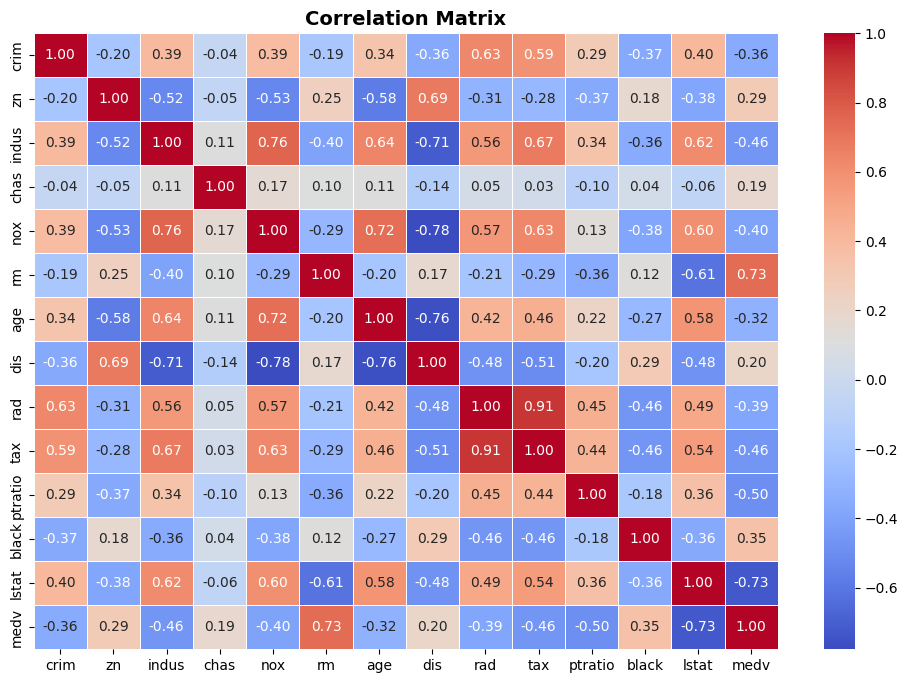

In [314]:
# Menambahkan sementara variabel target kedalam data untuk pengecekan korelasi menggunakan heatmap
train_data = X_train.copy()
train_data['medv'] = y_train

# heatmap correlation
plt.figure(figsize=(12,8))

sns.heatmap(train_data.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.show()

In [315]:
# Copy data train, test dan validation untuk model tanpa drop fitur
X_train_full = X_train.copy()
X_test_full = X_test.copy()
X_val_full = X_val.copy()

# Hapus fitur yang redundan
X_train = X_train.drop(columns = ['rad'])
X_test = X_test.drop(columns = ['rad'])
X_val = X_val.drop(columns = ['rad'])

**Insight**:

- Terindikasi adanya multicollinearity dimana `tax` dan `rad` memiliki nilai korelasi yang sangat tinggi yaitu 0.91.
- Diputuskan untuk melakukan drop pada variabel `rad` karena apabila dilihat nilai korelasi antara `tax` dan `rad` terhadap target `medv`, `tax` sedikit lebih baik dalam hal korelasi terhadap target.

## Recheck VIF

In [316]:
X = add_constant(X_train)

vif_df = pd.DataFrame([vif(X.values, i)
                      for i in range(X.shape[1])],
                      index = X.columns).reset_index()

vif_df.columns = ['feature', 'vif_score']
vif_df = vif_df.loc[vif_df.feature != 'const']
vif_df

,feature,vif_score
1,crim,1.6151
2,zn,2.4150
3,indus,3.5003
4,chas,1.0980
5,nox,4.5523
6,rm,1.9233
7,age,3.1198
8,dis,4.3904
9,tax,3.1914
10,ptratio,1.8046


**Insight**:

Terlihat sudah tidak ada variabel yang memiliki VIF Score yang tinggi (>5)

# Training Model Dengan Semua Fitur

## Ridge regression

In [317]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled_full = scaler.fit_transform(X_train_full)
X_val_scaled_full = scaler.transform(X_val_full)

alphas = [0.01, 0.1, 1, 10, 20, 50, 100]
best_alpha = None
best_rmse = float('inf')
ridge_best = None

# Define the model
for alpha in alphas:
  model = Ridge(alpha = alpha, random_state = 42)
  model.fit(X_train_scaled_full, y_train)

  y_pred_val_full = model.predict(X_val_scaled_full)
  rmse = np.sqrt(mean_squared_error(y_val, y_pred_val_full))
  print(f'RMSE of ridge regression model with alpha = {alpha} is {rmse}')

  if rmse < best_rmse:
    best_rmse = rmse
    best_alpha = alpha
    ridge_best = model

print(f'\nThe best model is model with alpha = {best_alpha} with RMSE score = {best_rmse}')

RMSE of ridge regression model with alpha = 0.01 is 4.825593983030511
RMSE of ridge regression model with alpha = 0.1 is 4.825519071326645
RMSE of ridge regression model with alpha = 1 is 4.824808643600835
RMSE of ridge regression model with alpha = 10 is 4.820720221565871
RMSE of ridge regression model with alpha = 20 is 4.820666406461432
RMSE of ridge regression model with alpha = 50 is 4.83570057720952
RMSE of ridge regression model with alpha = 100 is 4.884782515906688

The best model is model with alpha = 20 with RMSE score = 4.820666406461432


### Coefficient

In [318]:
coef_ridge = pd.DataFrame({
    'feature' : ['intercept'] + X_train_full.columns.tolist(),
    'coefficient' : [ridge_best.intercept_] + list(ridge_best.coef_)
})

coef_ridge

,feature,coefficient
0,intercept,22.7861
1,crim,-0.7579
2,zn,0.5081
3,indus,-0.0200
4,chas,0.8157
5,nox,-1.6185
6,rm,3.6072
7,age,-0.0684
8,dis,-2.5054
9,rad,1.0011


### Model evaluation

In [319]:
# Membuat prediksi hasil pada data training
y_predict_train_ridge = ridge_best.predict(X_train_scaled_full)

print('R-squared for training data is {}'.format(r2_score(y_train, y_predict_train_ridge)))
print('RMSE for training data is {}'.format(np.sqrt(mean_squared_error(y_train, y_predict_train_ridge))))
print('MAE for training data is {}'.format(mean_absolute_error(y_train, y_predict_train_ridge)))
print('MAPE for training data is {}'.format(mean_absolute_percentage_error(y_train, y_predict_train_ridge)))

R-squared for training data is 0.760619449025193
RMSE for training data is 4.662892116564331
MAE for training data is 3.2850206793460646
MAPE for training data is 0.16362345522362473


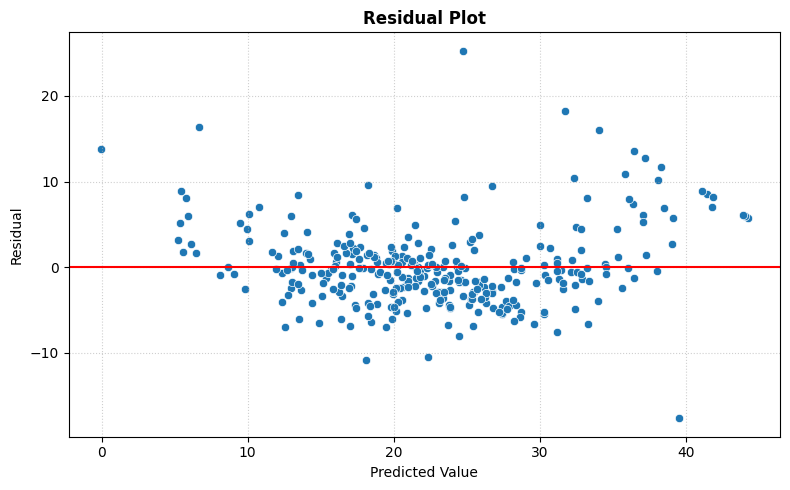

In [320]:
# Menghitung residual
residual_ridge = y_train - y_predict_train_ridge

df_residual_ridge = pd.DataFrame({
    'predicted_value': y_predict_train_ridge,
    'residual': residual_ridge
})

# Residual plot
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_residual_ridge, x="predicted_value", y="residual")
plt.axhline(0, color='red', linewidth=1.5)
plt.title('Residual Plot', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Value')
plt.ylabel('Residual')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Testing error

In [321]:
# Feature scaling
X_test_scaled_full = scaler.transform(X_test_full)
y_predict_test_full = ridge_best.predict(X_test_scaled_full)

# Predict
print('R-squared for testing data is {}'.format(r2_score(y_test, y_predict_test_full)))
print('RMSE for testing data is {}'.format(np.sqrt(mean_squared_error(y_test, y_predict_test_full))))
print('MAE for testing data is {}'.format(mean_absolute_error(y_test, y_predict_test_full)))
print('MAPE for testing data is {}'.format(mean_absolute_percentage_error(y_test, y_predict_test_full)))

R-squared for testing data is 0.6551241823155032
RMSE for testing data is 5.0290206234727215
MAE for testing data is 3.165660643852695
MAPE for testing data is 0.1692123031234926


## Lasso regression

In [322]:
alphas = [0.01, 0.1, 1, 10, 20, 50, 100]
best_alpha = None
best_rmse = float('inf')
lasso_best = None

# Define the model
for alpha in alphas:
  model = Lasso(alpha = alpha, random_state = 42)
  model.fit(X_train_scaled_full, y_train)

  y_pred_val_full = model.predict(X_val_scaled_full)
  rmse = np.sqrt(mean_squared_error(y_val, y_pred_val_full))
  print(f'RMSE of lasso regression model with alpha = {alpha} is {rmse}')

  if rmse < best_rmse:
    best_rmse = rmse
    best_alpha = alpha
    lasso_best = model

print(f'\nThe best model is model with alpha = {best_alpha} with RMSE score = {best_rmse}')

RMSE of lasso regression model with alpha = 0.01 is 4.828502600430609
RMSE of lasso regression model with alpha = 0.1 is 4.885270772240744
RMSE of lasso regression model with alpha = 1 is 5.2006314314003195
RMSE of lasso regression model with alpha = 10 is 8.432236862996595
RMSE of lasso regression model with alpha = 20 is 8.432236862996595
RMSE of lasso regression model with alpha = 50 is 8.432236862996595
RMSE of lasso regression model with alpha = 100 is 8.432236862996595

The best model is model with alpha = 0.01 with RMSE score = 4.828502600430609


### Coefficient

In [323]:
coef_lasso = pd.DataFrame({
    'feature' : ['intercept'] + X_train_full.columns.tolist(),
    'coefficient' : [lasso_best.intercept_] + list(lasso_best.coef_)
})

coef_lasso

,feature,coefficient
0,intercept,22.7861
1,crim,-0.8868
2,zn,0.7248
3,indus,0.2196
4,chas,0.7885
5,nox,-2.1794
6,rm,3.6306
7,age,-0.0445
8,dis,-3.1465
9,rad,1.6983


### Model evaluation

In [324]:
# Membuat prediksi hasil pada data training
y_predict_train_lasso = lasso_best.predict(X_train_scaled_full)

print('R-squared for training data is {}'.format(r2_score(y_train, y_predict_train_lasso)))
print('RMSE for training data is {}'.format(np.sqrt(mean_squared_error(y_train, y_predict_train_lasso))))
print('MAE for training data is {}'.format(mean_absolute_error(y_train, y_predict_train_lasso)))
print('MAPE for training data is {}'.format(mean_absolute_percentage_error(y_train, y_predict_train_lasso)))

R-squared for training data is 0.7642294141893411
RMSE for training data is 4.627599309916871
MAE for training data is 3.3270299924238302
MAPE for training data is 0.167460420587268


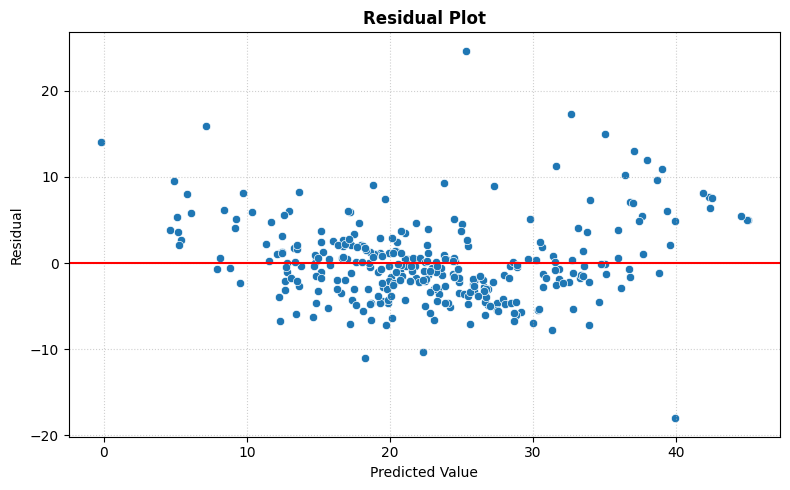

In [325]:
# Menghitung residual
residual_lasso = y_train - y_predict_train_lasso

df_residual_lasso = pd.DataFrame({
    'predicted_value': y_predict_train_lasso,
    'residual': residual_lasso
})

# Residual plot
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_residual_lasso, x="predicted_value", y="residual")
plt.axhline(0, color='red', linewidth=1.5)
plt.title('Residual Plot', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Value')
plt.ylabel('Residual')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Testing error

In [326]:
# Feature scaling
X_test_scaled_full = scaler.transform(X_test_full)
y_predict_test_full = lasso_best.predict(X_test_scaled_full)

# Predict
print('R-squared for testing data is {}'.format(r2_score(y_test, y_predict_test_full)))
print('RMSE for testing data is {}'.format(np.sqrt(mean_squared_error(y_test, y_predict_test_full))))
print('MAE for testing data is {}'.format(mean_absolute_error(y_test, y_predict_test_full)))
print('MAPE for testing data is {}'.format(mean_absolute_percentage_error(y_test, y_predict_test_full)))

R-squared for testing data is 0.657104786374237
RMSE for testing data is 5.014559127455207
MAE for testing data is 3.218039216163636
MAPE for testing data is 0.17248622361715063


# Training Model Dengan Fitur Pilihan

## Ridge regression

In [327]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

alphas = [0.01, 0.1, 1, 10, 20, 50, 100]
best_alpha = None
best_rmse = float('inf')
ridge_best_2 = None

# Define the model
for alpha in alphas:
  model = Ridge(alpha = alpha, random_state = 42)
  model.fit(X_train_scaled, y_train)

  y_pred_val = model.predict(X_val_scaled)
  rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
  print(f'RMSE of ridge regression model with alpha = {alpha} is {rmse}')

  if rmse < best_rmse:
    best_rmse = rmse
    best_alpha = alpha
    ridge_best_2 = model

print(f'\nThe best model is model with alpha = {best_alpha} with RMSE score = {best_rmse}')

RMSE of ridge regression model with alpha = 0.01 is 4.9620991592224195
RMSE of ridge regression model with alpha = 0.1 is 4.961651938681983
RMSE of ridge regression model with alpha = 1 is 4.957321610490609
RMSE of ridge regression model with alpha = 10 is 4.925196912769079
RMSE of ridge regression model with alpha = 20 is 4.90495932596545
RMSE of ridge regression model with alpha = 50 is 4.886779936924812
RMSE of ridge regression model with alpha = 100 is 4.908885927046559

The best model is model with alpha = 50 with RMSE score = 4.886779936924812


### Coefficient

In [328]:
coef_ridge_2 = pd.DataFrame({
    'feature' : ['intercept'] + X_train.columns.tolist(),
    'coefficient' : [ridge_best_2.intercept_] + list(ridge_best_2.coef_)
})

coef_ridge_2

,feature,coefficient
0,intercept,22.7861
1,crim,-0.5602
2,zn,0.3432
3,indus,-0.2360
4,chas,0.8389
5,nox,-1.1128
6,rm,3.5109
7,age,-0.0816
8,dis,-1.9311
9,tax,-0.2358


### Model evaluation

In [329]:
# prepare prediction result on train data
y_predict_train_ridge_2 = ridge_best_2.predict(X_train_scaled)

print('R-squared for training data is {}'.format(r2_score(y_train, y_predict_train_ridge_2)))
print('RMSE for training data is {}'.format(np.sqrt(mean_squared_error(y_train, y_predict_train_ridge_2))))
print('MAE for training data is {}'.format(mean_absolute_error(y_train, y_predict_train_ridge_2)))
print('MAPE for training data is {}'.format(mean_absolute_percentage_error(y_train, y_predict_train_ridge_2)))

R-squared for training data is 0.7487150401502383
RMSE for training data is 4.777428369079069
MAE for training data is 3.3305142536155112
MAPE for training data is 0.1632007323827312


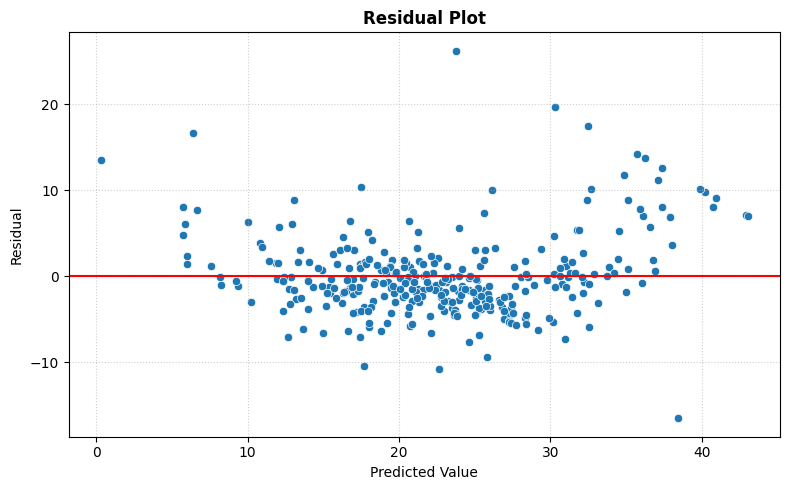

In [330]:
# calculate residuals
residual_ridge_2 = y_train - y_predict_train_ridge_2

df_residual_ridge_2 = pd.DataFrame({
    'predicted_value': y_predict_train_ridge_2,
    'residual': residual_ridge_2
})

# residual plot
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_residual_ridge_2, x="predicted_value", y="residual")
plt.axhline(0, color='red', linewidth=1.5)
plt.title('Residual Plot', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Value')
plt.ylabel('Residual')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Testing error

In [331]:
# Feature scaling
X_test_scaled = scaler.transform(X_test)
y_predict_test = ridge_best_2.predict(X_test_scaled)

# Predict
print('R-squared for testing data is {}'.format(r2_score(y_test, y_predict_test)))
print('RMSE for testing data is {}'.format(np.sqrt(mean_squared_error(y_test, y_predict_test))))
print('MAE for testing data is {}'.format(mean_absolute_error(y_test, y_predict_test)))
print('MAPE for testing data is {}'.format(mean_absolute_percentage_error(y_test, y_predict_test)))

R-squared for testing data is 0.6431314711180247
RMSE for testing data is 5.115712981958061
MAE for testing data is 3.2070314698470455
MAPE for testing data is 0.1704395736630923


## Lasso regression

In [332]:
alphas = [0.01, 0.1, 1, 10, 20, 50, 100]
best_alpha = None
best_rmse = float('inf')
lasso_best_2 = None

# Define the model
for alpha in alphas:
  model = Lasso(alpha = alpha, random_state = 42)
  model.fit(X_train_scaled, y_train)

  y_pred_val = model.predict(X_val_scaled)
  rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
  print(f'RMSE of lasso regression model with alpha = {alpha} is {rmse}')

  if rmse < best_rmse:
    best_rmse = rmse
    best_alpha = alpha
    lasso_best_2 = model

print(f'\nThe best model is model with alpha = {best_alpha} with RMSE score = {best_rmse}')

RMSE of lasso regression model with alpha = 0.01 is 4.957565461256394
RMSE of lasso regression model with alpha = 0.1 is 4.921687497224872
RMSE of lasso regression model with alpha = 1 is 5.200630821032169
RMSE of lasso regression model with alpha = 10 is 8.432236862996595
RMSE of lasso regression model with alpha = 20 is 8.432236862996595
RMSE of lasso regression model with alpha = 50 is 8.432236862996595
RMSE of lasso regression model with alpha = 100 is 8.432236862996595

The best model is model with alpha = 0.1 with RMSE score = 4.921687497224872


### Coefficient

In [333]:
coef_lasso_2 = pd.DataFrame({
    'feature' : ['intercept'] + X_train.columns.tolist(),
    'coefficient' : [lasso_best_2.intercept_] + list(lasso_best_2.coef_)
})

coef_lasso_2

,feature,coefficient
0,intercept,22.7861
1,crim,-0.5230
2,zn,0.3278
3,indus,-0.0000
4,chas,0.7707
5,nox,-1.6533
6,rm,3.7895
7,age,-0.0000
8,dis,-2.4611
9,tax,-0.0000


### Model evaluation

In [334]:
# prepare prediction result on train data
y_predict_train_lasso_2 = lasso_best_2.predict(X_train_scaled)

print('R-squared for training data is {}'.format(r2_score(y_train, y_predict_train_lasso_2)))
print('RMSE for training data is {}'.format(np.sqrt(mean_squared_error(y_train, y_predict_train_lasso_2))))
print('MAE for training data is {}'.format(mean_absolute_error(y_train, y_predict_train_lasso_2)))
print('MAPE for training data is {}'.format(mean_absolute_percentage_error(y_train, y_predict_train_lasso_2)))

R-squared for training data is 0.7569677527702418
RMSE for training data is 4.6983231879387475
MAE for training data is 3.300173986025632
MAPE for training data is 0.16430487368396474


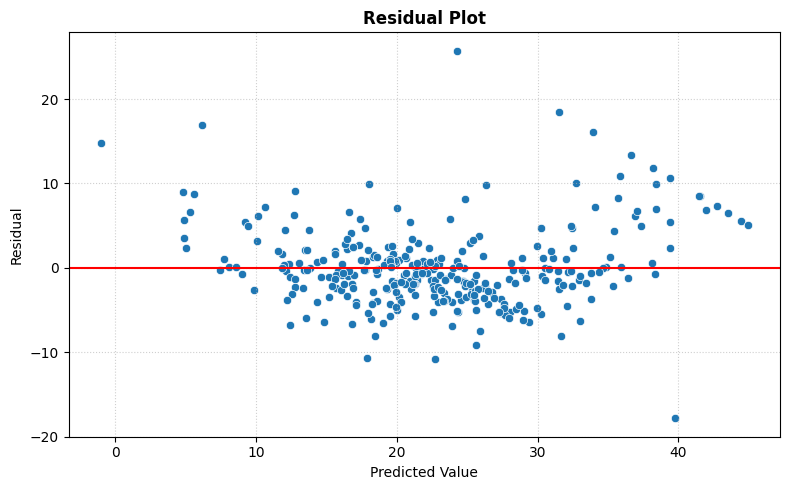

In [335]:
# calculate residuals
residual_lasso_2 = y_train - y_predict_train_lasso_2

df_residual_lasso_2 = pd.DataFrame({
    'predicted_value': y_predict_train_lasso_2,
    'residual': residual_lasso_2
})

# residual plot
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_residual_lasso_2, x="predicted_value", y="residual")
plt.axhline(0, color='red', linewidth=1.5)
plt.title('Residual Plot', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Value')
plt.ylabel('Residual')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Testing error

In [336]:
# Feature scaling
X_test_scaled = scaler.transform(X_test)
y_predict_test = lasso_best_2.predict(X_test_scaled)

# Predict
print('R-squared for testing data is {}'.format(r2_score(y_test, y_predict_test)))
print('RMSE for testing data is {}'.format(np.sqrt(mean_squared_error(y_test, y_predict_test))))
print('MAE for testing data is {}'.format(mean_absolute_error(y_test, y_predict_test)))
print('MAPE for testing data is {}'.format(mean_absolute_percentage_error(y_test, y_predict_test)))

R-squared for testing data is 0.6326646866943098
RMSE for testing data is 5.190191539152364
MAE for testing data is 3.2879453166719195
MAPE for testing data is 0.17715615549737793


# Perbandingan Semua Model

In [337]:
# Mengubah nama kolom coefficient pada tiap dataframe
df_ridge = coef_ridge.rename(columns={'coefficient': 'Ridge (Full)'})
df_lasso = coef_lasso.rename(columns={'coefficient': 'Lasso (Full)'})
df_ridge_2 = coef_ridge_2.rename(columns={'coefficient': 'Ridge (Selected)'})
df_lasso_2 = coef_lasso_2.rename(columns={'coefficient': 'Lasso (Selected)'})

# Menggabungkan keempat dataframe berdasarkan kolom fitur
coef_comparison = df_ridge.merge(df_lasso, on='feature', how='outer') \
                       .merge(df_ridge_2, on='feature', how='outer') \
                       .merge(df_lasso_2, on='feature', how='outer')

# Handling nilai NaN pada kolom yang di drop dengan nilai 0
coef_comparison = coef_comparison.fillna(0)

# Mengatur urutan fitur yang ditampilkan
custom_order = ['intercept'] + X_train_full.columns.tolist()
coef_comparison = coef_comparison.set_index('feature') \
                                 .reindex(custom_order) \
                                 .reset_index()
coef_comparison

,feature,Ridge (Full),Lasso (Full),Ridge (Selected),Lasso (Selected)
0,intercept,22.7861,22.7861,22.7861,22.7861
1,crim,-0.7579,-0.8868,-0.5602,-0.5230
2,zn,0.5081,0.7248,0.3432,0.3278
3,indus,-0.0200,0.2196,-0.2360,-0.0000
4,chas,0.8157,0.7885,0.8389,0.7707
5,nox,-1.6185,-2.1794,-1.1128,-1.6533
6,rm,3.6072,3.6306,3.5109,3.7895
7,age,-0.0684,-0.0445,-0.0816,-0.0000
8,dis,-2.5054,-3.1465,-1.9311,-2.4611
9,rad,1.0011,1.6983,0.0000,0.0000


In [338]:
# Membuat sebuah dictionary yang menampung seluruh model yang sudah dibuat sebelumnya
models = {
    'Model 1 (Ridge - Semua Fitur)': (ridge_best, X_test_scaled_full),
    'Model 2 (Lasso - Semua Fitur)': (lasso_best, X_test_scaled_full),
    'Model 3 (Ridge - Fitur Pilihan)': (ridge_best_2, X_test_scaled),
    'Model 4 (Lasso - Fitur Pilihan)': (lasso_best_2, X_test_scaled)
}

comparison_list = []

# Membuat metrik evaluasi untuk semua model
for model_name, (model_obj, X_data) in models.items():
    y_pred = model_obj.predict(X_data)

    comparison_list.append({
        'Model Name': model_name,
        'R-squared': r2_score(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'MAPE (%)': mean_absolute_percentage_error(y_test, y_pred) * 100
    })

comparison_df = pd.DataFrame(comparison_list)
comparison_df

,Model Name,R-squared,RMSE,MAE,MAPE (%)
0,Model 1 (Ridge - Semua Fitur),0.6551,5.0290,3.1657,16.9212
1,Model 2 (Lasso - Semua Fitur),0.6571,5.0146,3.2180,17.2486
2,Model 3 (Ridge - Fitur Pilihan),0.6431,5.1157,3.2070,17.0440
3,Model 4 (Lasso - Fitur Pilihan),0.6327,5.1902,3.2879,17.7156
